# Indicadores Derivados — PRF 2025
**Jan–Dez 2025 | 72.529 ocorrências | Autores: Francisco Lucas, Thyago Antonio & Alex Lopes**

Este notebook apresenta os gráficos de 5 KPIs derivados do indicador base **Acidente Fatal** (letalidade média geral de **7,18%**), cobrindo cinco dimensões distintas e complementares do problema: estrutural (tipo de pista), comportamental (causa do acidente), temporal (período do dia), ambiental (condição meteorológica) e geográfica (UF).

Todos os KPIs deste notebook são **calculados diretamente da base bruta** (`dados_prf.csv`, extraído da aba "Dados" da planilha original — 72.529 registros), usando `pandas`, e não a partir de valores pré-agregados. A coluna `mortos` não é usada nos cálculos por definir diretamente o alvo `acidente_fatal` (evitando target leakage), conforme orientação da aula de referência.

In [1]:
import pandas as pd                  # manipulação e agregação dos dados
import matplotlib.pyplot as plt      # geração dos gráficos
import matplotlib.ticker as mticker  # formatação dos eixos (ex.: eixo em %)
import numpy as np                   # operações numéricas auxiliares

# Ajustes visuais globais (fundo branco, tamanho de fonte padrão)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# Carrega a base bruta (equivalente à aba "Dados" da planilha original, 72.529 registros)
df = pd.read_csv('dados_prf.csv')

# Taxa de letalidade média geral: proporção de acidentes com acidente_fatal == 1
# Usada como linha de referência em quase todos os gráficos
TAXA_GLOBAL = df['acidente_fatal'].mean()

def pct(x):
    # Formata um número decimal (ex.: 0.0718) como percentual no padrão BR (7,18%)
    return f"{x*100:.2f}%".replace('.', ',')

def plot_kpi_bar(categorias, taxas, titulo, subtitulo, cor_destaque=None, figsize=(9,5)):
    # Função reutilizável: gráfico de barras verticais com taxa de fatalidade por categoria
    fig, ax = plt.subplots(figsize=figsize)

    # Destaca em laranja a barra da categoria passada em cor_destaque; demais ficam em azul
    cores = ['#e8734a' if cor_destaque and c == cor_destaque else '#3b5b7a' for c in categorias]
    bars = ax.bar(categorias, [t*100 for t in taxas], color=cores, edgecolor='none', width=0.6)

    # Linha tracejada vermelha marcando a taxa global de referência
    ax.axhline(TAXA_GLOBAL*100, color='#c0392b', linestyle='--', linewidth=1.5,
               label=f'Taxa Global de Referência ({pct(TAXA_GLOBAL)})')

    # Rótulo de valor (%) no topo de cada barra
    for b, t in zip(bars, taxas):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, pct(t),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Títulos, legenda e limpeza visual (remove bordas superior/direita)
    ax.set_ylabel('Taxa de Fatalidade (%)')
    ax.set_title(titulo, fontsize=13, fontweight='bold', loc='left', pad=12)
    if subtitulo:
        ax.text(0, 1.02, subtitulo, transform=ax.transAxes, fontsize=9.5, color='#555555')
    ax.legend(loc='upper right', frameon=False, fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

def plot_kpi_barh(categorias, taxas, titulo, subtitulo, destaques=(), figsize=(9,7)):
    # Função reutilizável: gráfico de barras horizontais (para listas longas de categorias)
    fig, ax = plt.subplots(figsize=figsize)

    # Destaca em laranja as categorias passadas em "destaques"; demais ficam em azul
    cores = ['#e8734a' if c in destaques else '#3b5b7a' for c in categorias]
    bars = ax.barh(categorias, [t*100 for t in taxas], color=cores)

    # Linha vertical tracejada com a taxa global de referência
    ax.axvline(TAXA_GLOBAL*100, color='#c0392b', linestyle='--', linewidth=1.5,
               label=f'Taxa Global de Referência ({pct(TAXA_GLOBAL)})')

    # Rótulo de valor (%) ao final de cada barra
    for b, t in zip(bars, taxas):
        ax.text(b.get_width()+0.4, b.get_y()+b.get_height()/2, pct(t),
                 va='center', fontsize=8.5)

    ax.invert_yaxis()  # mantém a categoria de maior taxa no topo
    ax.set_xlabel('Taxa de Fatalidade (%)')
    ax.set_title(titulo, fontsize=13, fontweight='bold', loc='left', pad=12)
    ax.text(0, 1.01, subtitulo, transform=ax.transAxes, fontsize=9.5, color='#555555')
    ax.legend(loc='lower right', frameon=False, fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    plt.tight_layout()
    plt.show()


## KPI 01 — Taxa de Fatalidade por Tipo de Pista

**Por que este KPI foi escolhido:** o tipo de pista (simples, dupla ou múltipla) é uma variável estrutural da rodovia, diretamente ligada a investimento em infraestrutura (duplicação). Medir a letalidade por tipo de pista transforma uma característica de engenharia viária em prioridade de política pública.

**Importância:** rodovias não duplicadas concentram tráfego em sentidos opostos na mesma faixa, o que aumenta o risco de colisões frontais — historicamente as mais letais. Esse KPI aponta onde o investimento em duplicação ou em fiscalização preventiva (ultrapassagem, faixas de espera) tem maior potencial de reduzir mortes.

**O que o gráfico mostra:** barras comparando a taxa de fatalidade (% de acidentes fatais sobre o total) em pista simples, dupla e múltipla, com a linha tracejada marcando a taxa global (7,18%). Pista simples aparece destacada por ficar bem acima dessa referência (9,86%, ~2× a taxa de pista dupla).

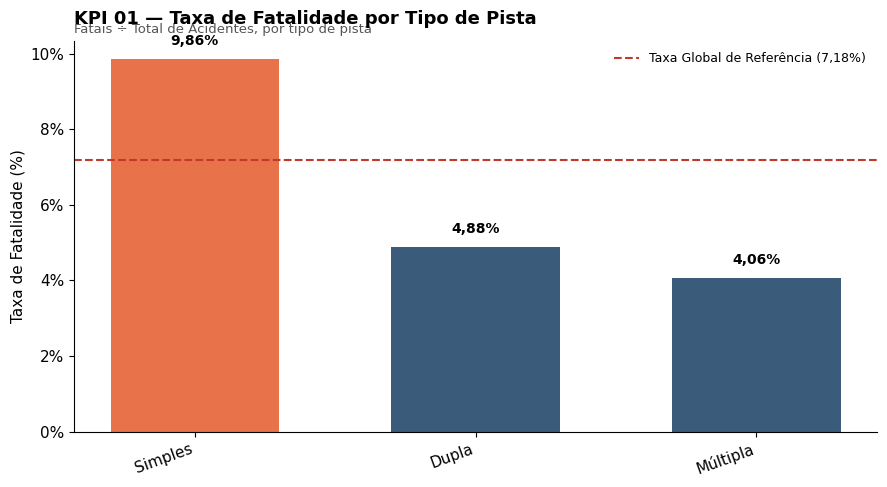

In [2]:
# KPI 01 — Taxa de Fatalidade por Tipo de Pista (calculado direto da base bruta)

# Agrupa por tipo de pista e soma os acidentes fatais (sum) e o total de acidentes (count)
tab01 = df.groupby('tipo_pista')['acidente_fatal'].agg(['sum', 'count'])
tab01 = tab01.loc[['Simples', 'Dupla', 'Múltipla']]  # fixa a ordem de exibição no gráfico

categorias = tab01.index.tolist()
taxas = (tab01['sum'] / tab01['count']).tolist()  # taxa = fatais / total, por categoria

plot_kpi_bar(categorias, taxas,
             'KPI 01 — Taxa de Fatalidade por Tipo de Pista',
             'Fatais ÷ Total de Acidentes, por tipo de pista',
             cor_destaque='Simples')  # destaca a categoria de maior risco


## KPI 02 — Taxa de Fatalidade por Causa do Acidente

**Por que este KPI foi escolhido:** diferente do tipo de acidente (que descreve o resultado da colisão), a causa descreve o comportamento ou evento que originou o acidente — é a variável mais diretamente acionável para fiscalização e educação de trânsito.

**Importância:** identificar quais comportamentos de risco (dirigir na contramão, ultrapassagem indevida, velocidade incompatível) mais elevam a chance de morte permite direcionar blitz, radares e campanhas educativas para comportamentos específicos, e não apenas para locais ou horários.

**O que o gráfico mostra:** taxa de fatalidade das causas mais frequentes (mínimo de 300 casos, para evitar ruído estatístico de categorias raras), ordenadas da mais letal para a menos letal, com a linha tracejada da taxa global (7,18%). "Transitar na contramão" se destaca por combinar alto volume (2.475 casos) com altíssima letalidade (29,7%, ~4× a taxa global) — um comportamento raro, mas extremamente perigoso quando ocorre, e diretamente combatível via fiscalização e sinalização.

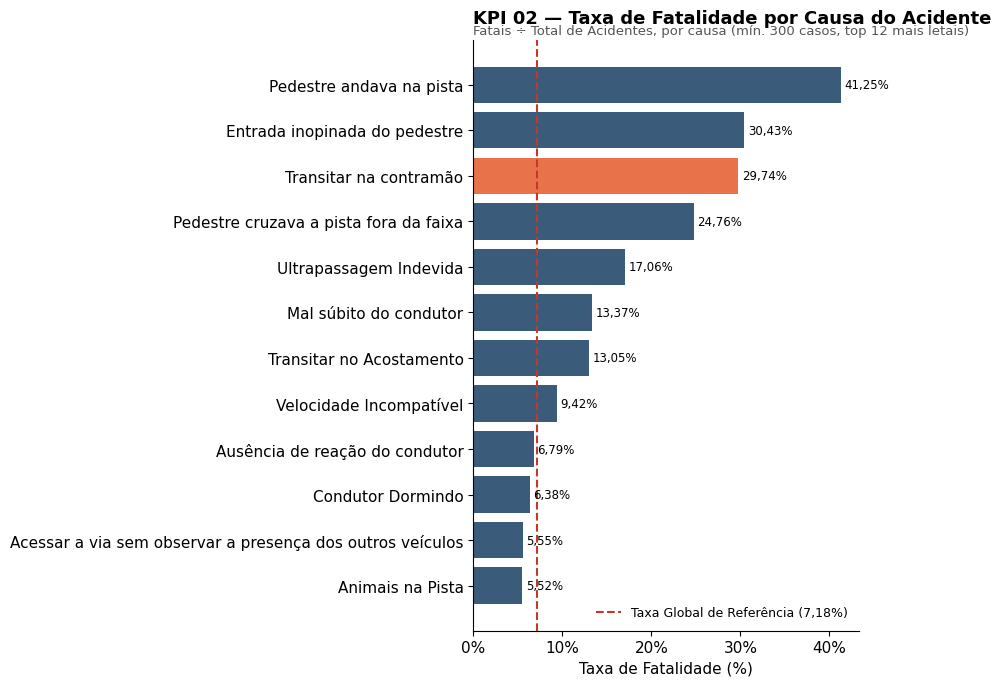

In [3]:
# KPI 02 — Taxa de Fatalidade por Causa do Acidente (calculado direto da base bruta)

# Agrupa por causa do acidente e calcula fatais / total de cada causa
tab02 = df.groupby('causa_acidente')['acidente_fatal'].agg(['sum', 'count'])
tab02['taxa'] = tab02['sum'] / tab02['count']

# Filtra causas com pelo menos 300 casos, para evitar que categorias raras (poucos casos)
# distorçam o ranking com taxas extremas e pouco confiáveis estatisticamente
tab02 = tab02[tab02['count'] >= 300]

# Ordena da causa mais letal para a menos letal e mantém as 12 mais letais
tab02 = tab02.sort_values('taxa', ascending=False).head(12)

categorias = tab02.index.tolist()
taxas = tab02['taxa'].tolist()

plot_kpi_barh(categorias, taxas,
              'KPI 02 — Taxa de Fatalidade por Causa do Acidente',
              'Fatais ÷ Total de Acidentes, por causa (mín. 300 casos, top 12 mais letais)',
              destaques=['Transitar na contramão'])  # comportamento mais letal e acionável


## KPI 03 — Percentual de Fatais por Período do Dia

**Por que este KPI foi escolhido:** o período do dia é uma variável operacional de baixo custo para agir — não exige obra, apenas realocação de efetivo e equipamentos (radares, viaturas) por horário.

**Importância:** menor visibilidade, fadiga do motorista e maior probabilidade de consumo de álcool concentram-se em horários noturnos, o que pode elevar a gravidade dos acidentes mesmo sem aumentar sua quantidade. Esse KPI orienta o escalonamento de turnos e a instalação de radares/pontos de fiscalização noturna.

**O que o gráfico mostra:** taxa de fatalidade para os quatro períodos do dia (amanhecer, pleno dia, anoitecer, plena noite), com a linha tracejada da taxa global (7,18%). Amanhecer e Plena Noite ficam acima da referência, próximos do dobro da taxa observada no período diurno.

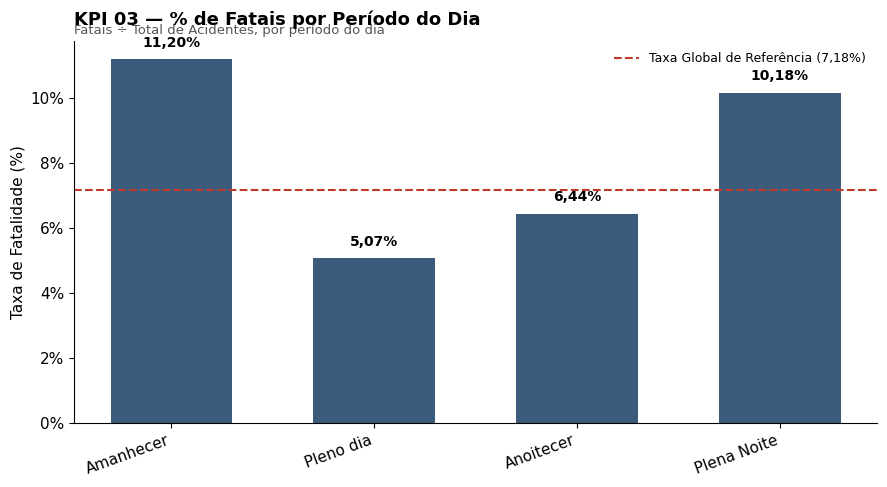

In [4]:
# KPI 03 — Percentual de Fatais por Período do Dia (calculado direto da base bruta)

# Agrupa por período do dia (fase_dia) e soma fatais / total de acidentes
tab03 = df.groupby('fase_dia')['acidente_fatal'].agg(['sum', 'count'])
tab03 = tab03.loc[['Amanhecer', 'Pleno dia', 'Anoitecer', 'Plena Noite']]  # ordem cronológica

categorias = tab03.index.tolist()
taxas = (tab03['sum'] / tab03['count']).tolist()  # taxa de fatalidade por período

plot_kpi_bar(categorias, taxas,
             'KPI 03 — % de Fatais por Período do Dia',
             'Fatais ÷ Total de Acidentes, por período do dia',
             cor_destaque=None)  # sem destaque único: dois períodos (amanhecer/noite) se sobressaem


## KPI 04 — Percentual de Fatais por Condição Meteorológica

**Por que este KPI foi escolhido:** condições meteorológicas são um fator externo, não controlável, mas previsível (previsão do tempo, sazonalidade em trechos de serra), o que permite ação preventiva coordenada em vez de reativa.

**Importância:** neblina e névoa reduzem a distância de visibilidade e o tempo de reação do motorista, fatores que aumentam a gravidade — não necessariamente a quantidade — dos acidentes. Esse KPI apoia decisões como ativação de painéis de mensagem variável e redução de velocidade regulamentada em trechos historicamente nebulosos.

**O que o gráfico mostra:** taxa de fatalidade por condição meteorológica no momento do acidente, com a linha tracejada da taxa global (7,18%). Nevoeiro/Neblina se destaca por ficar bem acima da referência (10,85%), enquanto condições de boa visibilidade (céu claro, sol) ficam próximas ou abaixo da média.

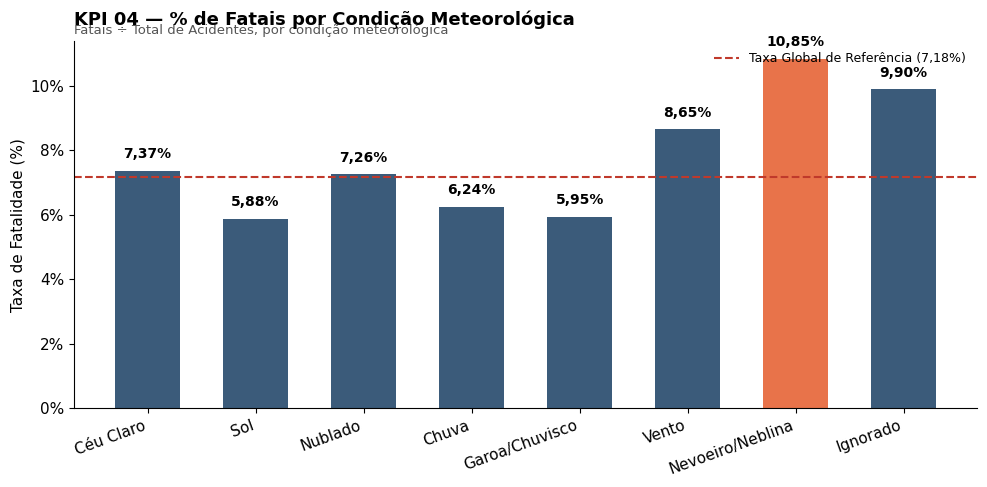

In [5]:
# KPI 04 — Percentual de Fatais por Condição Meteorológica (calculado direto da base bruta)

# Ordem de exibição das condições meteorológicas (da mais comum/segura à mais rara)
ordem04 = ['Céu Claro', 'Sol', 'Nublado', 'Chuva', 'Garoa/Chuvisco', 'Vento', 'Nevoeiro/Neblina', 'Ignorado']

# Agrupa por condição meteorológica e calcula fatais / total
tab04 = df.groupby('condicao_metereologica')['acidente_fatal'].agg(['sum', 'count'])
tab04 = tab04.loc[[c for c in ordem04 if c in tab04.index]]  # aplica a ordem, ignorando categorias ausentes

categorias = tab04.index.tolist()
taxas = (tab04['sum'] / tab04['count']).tolist()

plot_kpi_bar(categorias, taxas,
             'KPI 04 — % de Fatais por Condição Meteorológica',
             'Fatais ÷ Total de Acidentes, por condição meteorológica',
             cor_destaque='Nevoeiro/Neblina', figsize=(10,5))


## KPI 05 — Taxa de Fatalidade por UF

**Por que este KPI foi escolhido:** rankings por volume absoluto (ex: "MG lidera com 647 acidentes fatais") mostram concentração territorial, mas não risco — um estado com poucas rodovias federais pode concentrar poucos acidentes e ainda assim ter alto risco relativo por ocorrência. A taxa, e não a contagem, é o que orienta priorização de patrulhamento por risco.

**Importância:** dois estados podem ter o mesmo número absoluto de acidentes fatais e, ainda assim, ter perfis de risco muito diferentes — um deles pode ter menos acidentes no total, mas uma proporção muito maior deles terminando em morte. Esse KPI direciona recursos federais (efetivo, equipamentos, campanhas) para onde o risco por acidente é mais alto, complementando o ranking por volume.

**O que o gráfico mostra:** taxa de fatalidade por UF (mínimo de 200 casos, para uma estimativa estatisticamente mais confiável), ordenada da maior para a menor, com a linha tracejada da taxa global (7,18%). Maranhão (MA) lidera com 18,7% de letalidade — mais que o dobro da taxa global — mesmo não estando entre os estados de maior volume absoluto de acidentes fatais.

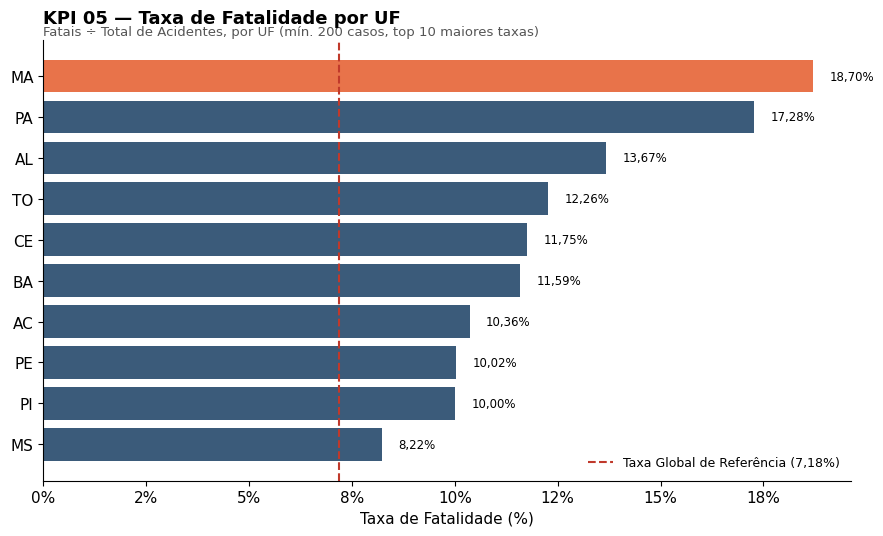

In [6]:
# KPI 05 — Taxa de Fatalidade por UF (calculado direto da base bruta)

# Agrupa por UF e calcula fatais / total de cada estado
tab05 = df.groupby('uf')['acidente_fatal'].agg(['sum', 'count'])
tab05['taxa'] = tab05['sum'] / tab05['count']

# Filtra UFs com pelo menos 200 casos, para evitar que estados com poucos registros
# (baixa exposição na malha federal) distorçam o ranking com taxas pouco confiáveis
tab05 = tab05[tab05['count'] >= 200]

# Ordena da UF mais letal para a menos letal e mantém as 10 mais letais
tab05 = tab05.sort_values('taxa', ascending=False).head(10)

categorias = tab05.index.tolist()
taxas = tab05['taxa'].tolist()

plot_kpi_barh(categorias, taxas,
              'KPI 05 — Taxa de Fatalidade por UF',
              'Fatais ÷ Total de Acidentes, por UF (mín. 200 casos, top 10 maiores taxas)',
              destaques=['MA'], figsize=(9,5.5))  # UF de maior risco relativo


## Painel Resumo — Comparativo dos 5 KPIs vs. Taxa Global

**Por que este painel foi incluído:** os 5 KPIs cobrem dimensões diferentes do problema (estrutural, comportamental, temporal, ambiental, geográfica) e usam bases de comparação distintas; reuni-los em um único gráfico permite priorizar entre eles, e não apenas dentro de cada um.

**O que o gráfico mostra:** a categoria de pior desempenho de cada KPI (pista simples, contramão, plena noite, neblina, Maranhão), com o múltiplo de quantas vezes cada uma supera a taxa global (7,18%). "Transitar na contramão" se destaca como o comportamento de maior risco relativo entre todos os KPIs analisados.

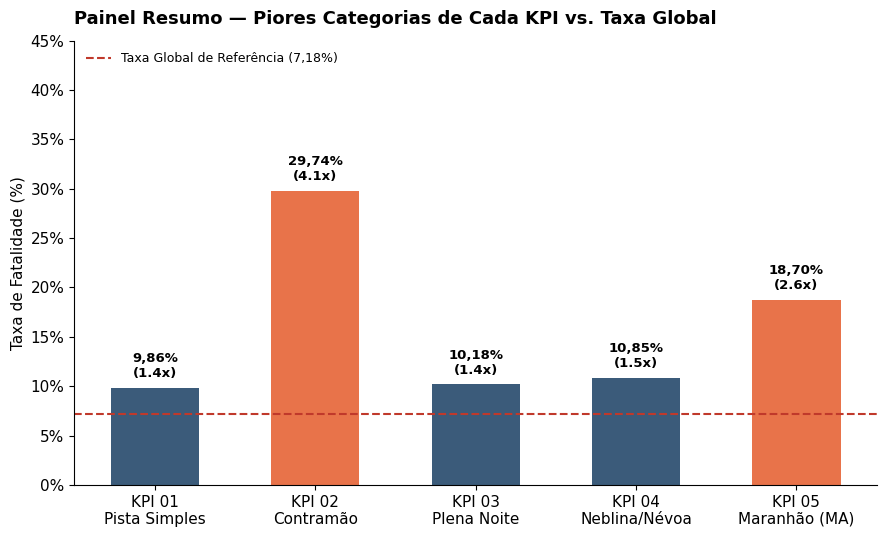

In [7]:
# Painel resumo comparativo — recalcula a pior categoria de cada KPI direto da base

# Cada linha repete a lógica de um KPI anterior, mas extrai só o valor da categoria de maior risco
v_kpi01 = df.groupby('tipo_pista')['acidente_fatal'].mean()['Simples']                    # pista simples

# Causa: mesmo filtro de volume mínimo (300 casos) usado no gráfico do KPI 02
causa_tab = df.groupby('causa_acidente')['acidente_fatal'].agg(['sum', 'count'])
causa_tab = causa_tab[causa_tab['count'] >= 300]
v_kpi02 = (causa_tab['sum'] / causa_tab['count'])['Transitar na contramão']               # contramão

v_kpi03 = df.groupby('fase_dia')['acidente_fatal'].mean()['Plena Noite']                  # plena noite
v_kpi04 = df.groupby('condicao_metereologica')['acidente_fatal'].mean()['Nevoeiro/Neblina']  # neblina

# UF: mesmo filtro de volume mínimo (200 casos) usado no gráfico do KPI 05
uf_tab = df.groupby('uf')['acidente_fatal'].agg(['sum', 'count'])
uf_tab = uf_tab[uf_tab['count'] >= 200]
v_kpi05 = (uf_tab['sum'] / uf_tab['count'])['MA']                                         # Maranhão

kpis = [
    'KPI 01\nPista Simples',
    'KPI 02\nContramão',
    'KPI 03\nPlena Noite',
    'KPI 04\nNeblina/Névoa',
    'KPI 05\nMaranhão (MA)',
]
valores = [v_kpi01, v_kpi02, v_kpi03, v_kpi04, v_kpi05]

fig, ax = plt.subplots(figsize=(9,5.5))

# Destaca em laranja os KPIs cuja taxa é pelo menos 2x a taxa global de referência
cores = ['#e8734a' if v/TAXA_GLOBAL >= 2 else '#3b5b7a' for v in valores]
bars = ax.bar(kpis, [v*100 for v in valores], color=cores, width=0.55)

# Linha tracejada com a taxa global geral (mesma referência usada nos demais KPIs)
ax.axhline(TAXA_GLOBAL*100, color='#c0392b', linestyle='--', linewidth=1.5,
           label=f'Taxa Global de Referência ({pct(TAXA_GLOBAL)})')

# Rótulo de valor (%) e múltiplo em relação à taxa global, no topo de cada barra
for b, v in zip(bars, valores):
    mult = v/TAXA_GLOBAL
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.8, f'{pct(v)}\n({mult:.1f}x)',
             ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_ylabel('Taxa de Fatalidade (%)')
ax.set_title('Painel Resumo — Piores Categorias de Cada KPI vs. Taxa Global', fontsize=13, fontweight='bold', loc='left', pad=12)
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(0, 45)
plt.tight_layout()
plt.show()


---
*Autores: Francisco Lucas, Thyago Antonio & Alex Lopes | Base: `dados_abertos_prf-datatran2025.csv` | Jan-Dez 2025 | 72.529 ocorrências*